# Momentum Strategy Comparison

A consolidated backtest comparing three strategies on NSE Nifty 100 stocks over a 5-year window.

| Name | Core Idea |
|---|---|
| Baseline Momentum | 52-week high breakout, fixed stop/target, no ranking |
| Low-Volatility Momentum | Low-vol universe + 6-month risk-adjusted ranking |
| Relative-Strength Low-Vol | Low-Volatility Momentum + relative-strength ranking vs Nifty + market-regime gate |
| Relative-Strength Low-Vol with MVO | Low-Volatility Momentum + relative-strength ranking vs Nifty + market-regime gate + Markowitz mean-variance optimization |

Each strategy runs the same analysis pipeline:
- Backtest
  - equity curve
  - trade-return distribution
- Analysis
  - alpha
  - beta
  - Sharpe ratio
- VaR numbers
  - Historical
  - VCV
  - Monte Carlo
- VaR Analysis
  - Traffic Light
  - Kupiec test


## Setup

In [1]:
!pip install niftystocks


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from niftystocks import ns
import matplotlib.dates as mdates
import scipy.stats as stats
from scipy.stats import chi2
from scipy.stats import t
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display
from scipy.optimize import minimize

INITIAL_CAPITAL    = 500_000
TURNOVER_THRESHOLD = 100_000_000
YEARS              = 5
RISK_FREE_DAILY    = 0.07 / 252   # 7 % p.a. risk-free rate (India)
RISK_FREE_ANNUAL   = 0.07
MVO_LOOKBACK       = 252              # trading days of history fed to MVO
CONFIDENCE_LEVELS  = [0.99, 0.95, 0.90]
NIFTY_TICKER       = '^NSEI'
START_DATE = (datetime.now() - timedelta(days=YEARS*365)).strftime('%Y-%m-%d')
END_DATE   = datetime.now().strftime('%Y-%m-%d')
print(f'Backtest window : {START_DATE}  →  {END_DATE}')


Backtest window : 2021-06-06  →  2026-06-05


## Data Download & Indicators

In [3]:
print('Fetching Nifty 100 tickers...')
nifty_tickers_raw = ns.get_nifty100()
tickers = [t + '.NS' for t in nifty_tickers_raw]

print(f'Downloading OHLCV for {len(tickers)} stocks ({YEARS} years)...')
raw_data = yf.download(tickers, start=START_DATE, end=END_DATE,
                        interval='1d', progress=False, auto_adjust=True)

close_prices = raw_data['Close'].ffill()
volumes      = raw_data['Volume'].fillna(0)

# ── Indicators shared across all three strategies ──────────
high_52w       = close_prices.rolling(252).max()           # 52-week high
low_10w        = close_prices.rolling(50).min()            # 10-week low
daily_turnover = close_prices * volumes
avg_turnover   = daily_turnover.rolling(20).mean()         # 20-day avg turnover

# additional indicators
daily_ret  = close_prices.pct_change()
vol_60d    = daily_ret.rolling(60).std() * np.sqrt(252)    # annualised 60-day vol
mom_126d   = close_prices.pct_change(126)                  # 6-month momentum

# additional data: Nifty for regime gate and relative-strength
nifty_raw      = yf.download(NIFTY_TICKER, start=START_DATE, end=END_DATE,
                              interval='1d', progress=False, auto_adjust=True)
nifty_close    = nifty_raw['Close'].squeeze()
nifty_sma50    = nifty_close.rolling(50).mean()
nifty_mom_126d = nifty_close.pct_change(126)

print('✓ All data and indicators ready.')


Fetching Nifty 100 tickers...


ERROR:yfinance:
8 Failed downloads:
ERROR:yfinance:['ADANITRANS.NS', 'HDFC.NS', 'TATAMOTORS.NS', 'MCDOWELL-N.NS', 'CADILAHC.NS', 'LTI.NS', 'PEL.NS', 'MOTHERSUMI.NS']: YFTzMissingError('possibly delisted; no timezone found')


✓ All data and indicators ready.


## Shared Analysis Helper Functions

In [4]:
# ── Equity curve + trade-return distribution ──────────────
import plotly.graph_objects as go
from plotly.subplots import make_subplots as plotly_make_subplots

def plot_equity_and_distribution(port_df, completed_trades, strategy_name):
    start_dt       = datetime.strptime(START_DATE, '%Y-%m-%d')
    one_year_later = start_dt + timedelta(days=365)

    port_df = port_df.copy()
    port_df['Date']     = pd.to_datetime(port_df['Date'])
    port_df['Drawdown'] = (
        (port_df['Value'].cummax() - port_df['Value']) / port_df['Value'].cummax()
    )

    # Nifty benchmark scaled to INITIAL_CAPITAL at the 1-year mark
    nifty_d       = yf.download(NIFTY_TICKER, start=START_DATE, end=END_DATE,
                                 interval='1d', progress=False, auto_adjust=True)['Close'].squeeze()
    nifty_d.index = pd.to_datetime(nifty_d.index)
    nifty_aln     = nifty_d.reindex(port_df['Date']).ffill().bfill()
    idx_st        = (port_df['Date'] >= one_year_later).idxmax()
    nifty_vals    = (nifty_aln.values / nifty_aln.iloc[idx_st]) * INITIAL_CAPITAL

    # Filter to post-warmup window
    mask        = port_df['Date'] >= one_year_later
    plot_df     = port_df[mask].reset_index(drop=True)
    plot_nifty  = nifty_vals[mask.values]

    # Max drawdown span
    max_dd_idx = plot_df['Drawdown'].idxmax()
    peak_idx   = plot_df.loc[:max_dd_idx, 'Value'].idxmax()
    dd_start   = plot_df.loc[peak_idx, 'Date']
    dd_end     = plot_df.loc[max_dd_idx, 'Date']

    # ── Interactive equity curve (Plotly) ─────────────────
    fig = go.Figure()

    # Max drawdown shading
    fig.add_vrect(
        x0=dd_start, x1=dd_end,
        fillcolor='red', opacity=0.2,
        layer='below', line_width=0,
        annotation_text='Max Drawdown', annotation_position='top left',
        annotation_font_size=10, annotation_font_color='red'
    )

    # Portfolio value (primary y-axis)
    fig.add_trace(go.Scatter(
        x=plot_df['Date'], y=plot_df['Value'],
        name='Portfolio', line=dict(color='blue', width=1.8),
        hovertemplate='%{x|%d-%b-%Y}<br>Portfolio: ₹%{y:,.0f}<extra></extra>'
    ))

    # Nifty benchmark (primary y-axis)
    fig.add_trace(go.Scatter(
        x=plot_df['Date'], y=plot_nifty,
        name='Nifty 50', line=dict(color='purple', width=1.4, dash='dot'),
        opacity=0.8,
        hovertemplate='%{x|%d-%b-%Y}<br>Nifty (scaled): ₹%{y:,.0f}<extra></extra>'
    ))

    # Active trades (secondary y-axis)
    fig.add_trace(go.Scatter(
        x=plot_df['Date'], y=plot_df['Num_Trades'],
        name='Active Trades', line=dict(color='green', width=1.2, dash='dash'),
        opacity=0.6, yaxis='y2',
        hovertemplate='%{x|%d-%b-%Y}<br>Active Trades: %{y}<extra></extra>'
    ))

    fig.update_layout(
        title=dict(text=f'{strategy_name} — Portfolio PnL (Equity Curve)', font_size=14),
        xaxis=dict(title='Date', showgrid=True, gridcolor='rgba(200,200,200,0.3)'),
        yaxis=dict(title='Portfolio Value (₹)', titlefont_color='blue',
                   tickfont_color='blue', showgrid=True, gridcolor='rgba(200,200,200,0.3)'),
        yaxis2=dict(title='Active Trades', titlefont_color='green',
                    tickfont_color='green', overlaying='y', side='right', showgrid=False),
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        hovermode='x unified',
        width=1000, height=500,
        plot_bgcolor='white', paper_bgcolor='white',
        margin=dict(l=60, r=60, t=70, b=50)
    )
    fig.show()
    print('\n')
    # ── Static trade-return distribution (Matplotlib) ─────
    fig2, ax2 = plt.subplots(figsize=(5, 3))
    ax2.hist(completed_trades, bins=20, edgecolor='black', color='teal')
    ax2.set_title(f'{strategy_name} — Trade Return Distribution')
    ax2.set_xlabel('Return (%)'); ax2.set_ylabel('Frequency')
    plt.tight_layout(); plt.show()

    print(f'  Completed Trades : {len(completed_trades)}')
    print(f'  Max Drawdown     : {port_df["Drawdown"].max()*100:.2f}%')
    print(f'  Final Value      : ₹{port_df["Value"].iloc[-1]:,.2f}')

def get_max_drawdown(portfolio_df):
    temp_df = portfolio_df.copy()
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Drawdown'] = ((temp_df['Value'].cummax() - temp_df['Value']) / temp_df['Value'].cummax())
    return temp_df['Drawdown'].max() * 100

# ── Alpha / Beta / Sharpe ──────────────────────────────────
def compute_alpha_beta_sharpe(port_df, strategy_name):
    start_dt       = datetime.strptime(START_DATE, '%Y-%m-%d')
    one_year_later = start_dt + timedelta(days=365)

    port_df = port_df.copy()
    port_df['Date'] = pd.to_datetime(port_df['Date'])
    filt            = port_df.set_index('Date')
    filt            = filt[filt.index >= one_year_later]
    daily_rets      = filt['Value'].pct_change().dropna()

    nifty_d    = yf.download(NIFTY_TICKER, start=str(one_year_later.date()),
                              end=END_DATE, interval='1d',
                              progress=False, auto_adjust=True)
    nifty_rets = nifty_d['Close'].pct_change().dropna().squeeze()

    common = daily_rets.index.intersection(nifty_rets.index)
    pr, nr = daily_rets.loc[common], nifty_rets.loc[common]
    ep, en = pr - RISK_FREE_DAILY, nr - RISK_FREE_DAILY

    # Covariance / Variance formula
    beta_cov      = pr.cov(en) / nr.var()
    ann_alpha_cov = (ep.mean() - beta_cov * en.mean()) * 252 * 100
    sharpe = (pr.mean() - RISK_FREE_DAILY) / pr.std() * np.sqrt(252)

    print(f'\n--- Alpha and Beta Calculation (using formulas) ---')
    print(f'Beta (Covariance/Variance Formula): {beta_cov:.2f}')
    print(f'Annualized Alpha (Formula-based): {ann_alpha_cov:.2f}%')
    print(f'\n--- Portfolio Sharpe Ratio ---')
    print(f'Daily Sharpe Ratio: {(pr.mean()-RISK_FREE_DAILY)/pr.std():.4f}')
    print(f'Annualized Sharpe Ratio: {sharpe:.4f}')

    return {'beta'  : round(beta_cov,    4),
            'alpha' : round(ann_alpha_cov, 2),
            'sharpe': round(sharpe,       4),
            'daily_rets': daily_rets}


# ── VaR Analysis ───────────────────────────────────────────
def compute_var_analysis(final_active_trades, strategy_name):
    if not final_active_trades:
        print('No active trades at end — skipping VaR.'); return {}

    hold_df = pd.DataFrame(final_active_trades)[['symbol','qty']].rename(
        columns={'symbol':'Symbol','qty':'Quantity'})
    symbols = hold_df['Symbol'].tolist()

    # Current prices
    curr_px = {}
    for sym in symbols:
        ticker_data = yf.download(sym, period='1d', interval='1m', progress=False)
        if not ticker_data.empty:
          # Use the last available closing price for the current day and convert to scalar
          curr_px[sym] = ticker_data['Close'].iloc[-1].item()
        else:
          # Fallback for when '1m' interval might not return data for the current day
          # or if the market is closed and last day's close is needed.
          ticker_data = yf.download(sym, period='2d', interval='1d', progress=False)
          curr_px[sym] = ticker_data['Close'].iloc[-1].item()


    hold_df['Current_Price'] = hold_df['Symbol'].map(curr_px)
    hold_df = hold_df.dropna(subset=['Current_Price'])

    # Check if hold_df is empty after dropping NaNs
    if hold_df.empty:
        print(f'No valid holdings with current prices for {strategy_name} — skipping VaR.'); return {}

    hold_df['Current_Value'] = hold_df['Quantity'] * hold_df['Current_Price']
    cpv = hold_df['Current_Value'].sum()
    hold_df['Weight'] = hold_df['Current_Value'] / cpv
    symbols = hold_df['Symbol'].tolist()
    weights = hold_df['Weight'].values

    print(f'\n--- Portfolio Holdings Analysis ---')
    print(f'Current holdings value: ₹{cpv:,.2f}')
    display(hold_df[['Symbol','Quantity','Current_Price','Current_Value','Weight']].round(4))

    # 5-year historical data for VaR
    hist_start = (datetime.now() - timedelta(days=5*365)).strftime('%Y-%m-%d')
    hdata      = yf.download(symbols, start=hist_start, interval='1d',
                              progress=False, auto_adjust=True)['Close'].ffill()
    pct_rets   = hdata[symbols].pct_change().dropna()
    log_rets   = np.log(hdata[symbols] / hdata[symbols].shift(1)).dropna()

    w_ser    = pd.Series(dict(zip(symbols, weights)))
    port_pr  = pct_rets.dot(w_ser)
    cov_mat  = log_rets.cov().values
    corr_mat = log_rets.corr().values
    mu_arr   = log_rets.mean().values
    sig_arr  = log_rets.std().values

    var_table = {}
    for ci in CONFIDENCE_LEVELS:
        ci_label = f'{int(ci*100)}%'
        a_ci     = 1 - ci

        # Historical
        sr    = port_pr.sort_values()
        idx   = max(1, int(np.ceil(len(sr) * a_ci)))
        v_h   = -sr.iloc[idx - 1] * cpv

        # Variance-Covariance
        port_var = float(weights @ cov_mat @ weights) # A @ B = (np.matmul(A, B.T)).T
        v_vcv    = -(port_pr.mean() + np.sqrt(port_var) * stats.norm.ppf(a_ci)) * cpv

        # Monte Carlo (correlated GBM, one-step)
        N_SIM  = 10_000
        reg_c  = corr_mat + np.eye(len(symbols)) * 1e-8
        chol   = np.linalg.cholesky(reg_c)
        rng    = np.random.default_rng(42)
        z      = rng.standard_normal((len(symbols), N_SIM))
        cz     = (chol @ z).T
        sim_r  = mu_arr + sig_arr * cz
        ps     = sim_r @ weights
        mc_idx = max(1, int(np.ceil(N_SIM * a_ci)))
        v_mc   = -np.sort(ps)[mc_idx - 1] * cpv

        var_table[ci_label] = {
            'Historical (Holdings)' : round(v_h,   0),
            'Variance-Covariance'   : round(v_vcv, 0),
            'Monte Carlo Simulation': round(v_mc,  0),
        }

    var_df = pd.DataFrame(var_table)
    var_df.index.name = 'VaR Method'
    print('\n--- VaR Results Summary (Absolute Loss in ₹) ---')
    display(var_df)

    daily_pnl = port_pr * cpv

    # Traffic Light (99% CI, 252 days)
    pnl_252 = daily_pnl.tail(252)
    print('\n--- Traffic Light Analysis ---')
    for method in ['Historical (Holdings)', 'Variance-Covariance', 'Monte Carlo Simulation']:
        b   = int((pnl_252 < -var_table['99%'][method]).sum())
        lbl = 'Green' if b <= 4 else ('Yellow' if b <= 9 else 'Red')
        print(f'{method}: {lbl} ({b} breaches)')

    # Kupiec Test (95% CI, up to 504 days)
    n_k   = min(504, len(daily_pnl))
    pnl_k = daily_pnl.tail(n_k)
    a_k   = 0.05
    kupiec = {}
    print(f'\n--- Kupiec Test Analysis ---')
    for method in ['Historical (Holdings)', 'Variance-Covariance', 'Monte Carlo Simulation']:
        b = int((pnl_k < -var_table['95%'][method]).sum())
        if b == 0:
            lbl, pval = 'Good', 1.0
        else:
            p_hat = min(b / n_k, 1 - 1e-10)
            lr    = -2 * np.log(
                ((a_k**b) * ((1 - a_k)**(n_k - b))) /
                ((p_hat**b) * ((1 - p_hat)**(n_k - b)))
            )
            pval = float(chi2.sf(lr, df=1))
            lbl  = 'Good' if pval >= 0.05 else 'Bad'
        kupiec[method] = lbl
        print(f'{method}: {lbl} ({b} breaches, p-value: {pval:.3f})')

    return {'var_table': var_table, 'kupiec': kupiec, 'cpv': cpv}


print('✓ Helper functions defined.')

✓ Helper functions defined.


---
## Original Strategy — Momentum Strategy

The original strategy trades 52-week high breakouts on Nifty 100 stocks with sufficient liquidity.

| Parameter | Value |
|---|---|
| Universe | Nifty 100 |
| Initial capital | ₹5,00,000 |
| Max positions | 20 |
| Entry | Price ≥ 52-week high on prev. Friday AND 20-day avg turnover ≥ ₹10 Cr |
| Stop-loss | max(0.70 × entry, 10-week low), updated every Monday |
| Target | 1.6 × entry |
| Ranking | None (first qualifying stock wins the slot) |


In [5]:
def run_backtest_original():
    """Original baseline momentum strategy."""
    MAX_POS = 20
    cash = INITIAL_CAPITAL
    portfolio_history, completed_trades, active_trades = [], [], []

    for date, row in close_prices.iterrows():
        # Mark-to-market
        current_val = cash
        for trade in active_trades:
            p = row.get(trade['symbol'], np.nan)
            if not np.isnan(p):
                current_val += p * trade['qty']
        portfolio_history.append({'Date': date, 'Value': current_val,
                                   'Num_Trades': len(active_trades)})

        # ── Exits ──────────────────────────────────────────────
        for trade in active_trades[:]:
            curr_price = row.get(trade['symbol'], np.nan)
            if np.isnan(curr_price): continue
            # Trailing 10-week low stop updated every Monday
            if date.weekday() == 0:
                try:
                    new_sl = float(low_10w.loc[date, trade['symbol']])
                    if not np.isnan(new_sl):
                        trade['stop_loss'] = max(trade['stop_loss'], new_sl)
                except Exception: pass
            if curr_price >= trade['target'] or curr_price <= trade['stop_loss']:
                cash += curr_price * trade['qty']
                ret = (curr_price - trade['entry_price']) / trade['entry_price']
                completed_trades.append(ret * 100)
                active_trades.remove(trade)

        # ── Entries (Monday only) ──────────────────────────────
        if date.weekday() != 0 or len(active_trades) >= MAX_POS:
            continue
        prev_friday = date - timedelta(days=3)
        if prev_friday not in high_52w.index: continue

        for symbol in tickers:
            if len(active_trades) >= MAX_POS: break
            if any(t['symbol'] == symbol for t in active_trades): continue
            ep = row.get(symbol, np.nan)
            if np.isnan(ep): continue
            try:
                pf_close = float(close_prices.loc[prev_friday, symbol])
                pf_52h   = float(high_52w.loc[prev_friday, symbol])
                pf_turn  = float(avg_turnover.loc[prev_friday, symbol])
            except Exception: continue
            if any(np.isnan(v) for v in [pf_close, pf_52h]): continue

            if pf_close >= pf_52h and pf_turn >= TURNOVER_THRESHOLD:
                allocation = INITIAL_CAPITAL / MAX_POS
                if cash < allocation: continue
                qty = int(allocation // ep)
                if qty <= 0: continue
                try:
                    sl_10w = float(low_10w.loc[date, symbol])
                except Exception:
                    sl_10w = ep * 0.70
                sl = max(ep * 0.70,
                         sl_10w if not np.isnan(sl_10w) else ep * 0.70)
                cash -= qty * ep
                active_trades.append({
                    'symbol': symbol, 'entry_price': ep, 'qty': qty,
                    'target': ep * 1.6, 'stop_loss': sl
                })

    return pd.DataFrame(portfolio_history), completed_trades, active_trades


print('Running Original strategy backtest...')
port_orig, trades_orig, final_orig = run_backtest_original()
print('✓ Done.')


Running Original strategy backtest...
✓ Done.


### Original — Results

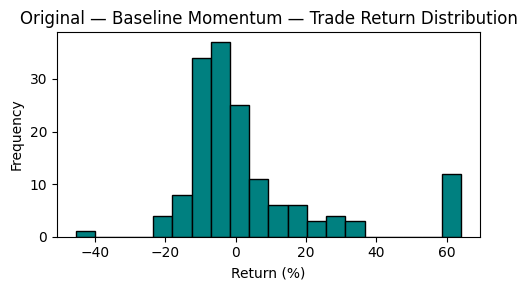

  Completed Trades : 154
  Max Drawdown     : 13.85%
  Final Value      : ₹660,861.29


In [6]:
plot_equity_and_distribution(port_orig, trades_orig, 'Original — Baseline Momentum')


In [7]:
metrics_orig = compute_alpha_beta_sharpe(port_orig, 'Original — Baseline Momentum')



--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.53
Annualized Alpha (Formula-based): -0.81%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0040
Annualized Sharpe Ratio: 0.0630


**Key observations:**
- No ranking: the first qualifying stocks fill slots regardless of momentum strength, leaving the best candidates outside the portfolio on busy Mondays.
- Wide stop (30% below entry) allows large per-trade losses, inflating return volatility and suppressing Sharpe.
- No vol filter means the portfolio can hold high-beta stocks, driving beta toward or above 1.


In [8]:
var_orig = compute_var_analysis(final_orig, 'Original — Baseline Momentum')


--- Portfolio Holdings Analysis ---
Current holdings value: ₹456,837.88


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,TORNTPHARM.NS,6,4440.6001,26643.6006,0.0583
1,NMDC.NS,318,93.2100,29640.7797,0.0649
2,NTPC.NS,69,361.8000,24964.1992,0.0546
3,SIEMENS.NS,7,3704.8999,25934.2993,0.0568
4,AUROPHARMA.NS,19,1469.0000,27911.0000,0.0611
5,TITAN.NS,5,4230.2002,21151.0010,0.0463
6,ADANIPORTS.NS,15,1819.4000,27291.0004,0.0597
7,ADANIGREEN.NS,20,1489.3000,29786.0010,0.0652
8,NESTLEIND.NS,17,1377.4000,23415.8004,0.0513
9,HINDALCO.NS,23,1102.5000,25357.5000,0.0555



--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),14359.0,8482.0,5701.0
Variance-Covariance,11575.0,8073.0,6205.0
Monte Carlo Simulation,11763.0,7911.0,6084.0



--- Traffic Light Analysis ---
Historical (Holdings): Green (1 breaches)
Variance-Covariance: Green (3 breaches)
Monte Carlo Simulation: Green (3 breaches)

--- Kupiec Test Analysis ---
Historical (Holdings): Good (28 breaches, p-value: 0.574)
Variance-Covariance: Good (30 breaches, p-value: 0.340)
Monte Carlo Simulation: Good (33 breaches, p-value: 0.127)


---
## Low-Volatility Momentum Strategy

Restricts the entry universe to low-volatility stocks (ann. vol < 45%) and ranks candidates by risk-adjusted 6-month momentum (return ÷ volatility). Uses a tighter stop floor and fewer positions for higher conviction.

| Parameter | Original | S3 |
|---|---|---|
| Universe | All Nifty 100 | Nifty 100 with **ann. vol < 45%** |
| Stop-loss floor | 0.70 × entry | **0.87 × entry** |
| Target | 1.6 × entry | **1.7 × entry** |
| Max positions | 20 | **15** |
| Ranking | None | **mom_126d / vol_60d** |


In [9]:
def run_backtest_low_vol_mom():
    """Low-Volatility Momentum."""
    MAX_POS       = 15
    VOL_THRESHOLD = 0.45

    cash = INITIAL_CAPITAL
    portfolio_history, completed_trades, active_trades = [], [], []

    for date, row in close_prices.iterrows():
        curr_val = cash
        for t in active_trades:
            p = row.get(t['symbol'], np.nan)
            if not np.isnan(p): curr_val += p * t['qty']
        portfolio_history.append({'Date': date, 'Value': curr_val,
                                   'Num_Trades': len(active_trades)})

        # ── Exits ──────────────────────────────────────────────
        for t in active_trades[:]:
            p = row.get(t['symbol'], np.nan)
            if np.isnan(p): continue
            if date.weekday() == 0:
                try:
                    new_sl = float(low_10w.loc[date, t['symbol']])
                    if not np.isnan(new_sl):
                        t['stop_loss'] = max(t['stop_loss'], new_sl)
                except Exception: pass
            if p >= t['target'] or p <= t['stop_loss']:
                cash += p * t['qty']
                completed_trades.append(
                    (p - t['entry_price']) / t['entry_price'] * 100)
                active_trades.remove(t)

        # ── Entries (Monday only) ──────────────────────────────
        if date.weekday() != 0 or len(active_trades) >= MAX_POS:
            continue
        prev_friday = date - timedelta(days=3)
        if prev_friday not in high_52w.index: continue

        picks = []
        for sym in tickers:
            p = row.get(sym, np.nan)
            if np.isnan(p) or any(t['symbol'] == sym for t in active_trades): continue
            try:
                pf_close  = float(close_prices.loc[prev_friday, sym])
                pf_52h    = float(high_52w.loc[prev_friday, sym])
                pf_turn   = float(avg_turnover.loc[prev_friday, sym])
                pf_vol    = float(vol_60d.loc[prev_friday, sym])
                pf_mom126 = float(mom_126d.loc[prev_friday, sym])
            except Exception: continue
            if any(np.isnan(v) for v in [pf_close, pf_52h, pf_vol, pf_mom126]):
                continue

            if (pf_close >= pf_52h and
                    pf_turn  >= TURNOVER_THRESHOLD and
                    pf_vol   <  VOL_THRESHOLD):
                score = pf_mom126 / (pf_vol + 0.01)
                picks.append((sym, score))

        picks.sort(key=lambda x: x[1], reverse=True)

        for sym, _ in picks:
            if len(active_trades) >= MAX_POS: break
            ep = row.get(sym, np.nan)
            if np.isnan(ep): continue
            alloc = INITIAL_CAPITAL / MAX_POS
            if cash < alloc: continue
            qty = int(alloc // ep)
            if qty <= 0: continue
            try:
                sl_10w = float(low_10w.loc[date, sym])
            except Exception:
                sl_10w = ep * 0.87
            sl = max(ep * 0.87, sl_10w if not np.isnan(sl_10w) else ep * 0.87)
            cash -= qty * ep
            active_trades.append({
                'symbol': sym, 'entry_price': ep, 'qty': qty,
                'target': ep * 1.7, 'stop_loss': sl
            })

    return pd.DataFrame(portfolio_history), completed_trades, active_trades


print('Running Strategy 3 backtest...')
port_low_vol_mom, trades_low_vol_mom, final_low_vol_mom = run_backtest_low_vol_mom()
print('✓ Done.')


Running Strategy 3 backtest...
✓ Done.


### Low Volitility Momentum Strategy — Results

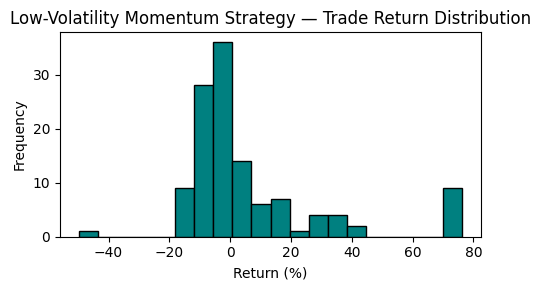

  Completed Trades : 121
  Max Drawdown     : 13.10%
  Final Value      : ₹762,666.90


In [10]:
plot_equity_and_distribution(port_low_vol_mom, trades_low_vol_mom, 'Low-Volatility Momentum Strategy')


In [11]:
metrics_low_vol_mom = compute_alpha_beta_sharpe(port_low_vol_mom, 'Low-Volatility Momentum Strategy')



--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.55
Annualized Alpha (Formula-based): 2.86%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0265
Annualized Sharpe Ratio: 0.4214


**Key observations:**
- Risk-adjusted ranking (momentum ÷ volatility) selects positions with a higher expected Sharpe, improving trade quality.
- The tighter stop (0.87 vs 0.70) halves the maximum per-trade loss, significantly reducing return variance.


In [12]:
var_low_vol_mom = compute_var_analysis(final_low_vol_mom, 'Low-Volatility Momentum Strategy')



--- Portfolio Holdings Analysis ---
Current holdings value: ₹485,017.70


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,TORNTPHARM.NS,9,4439.2002,39952.8018,0.0824
1,NMDC.NS,424,93.2600,39542.2409,0.0815
2,COALINDIA.NS,79,474.4500,37481.5510,0.0773
3,NTPC.NS,92,361.7000,33276.4011,0.0686
4,AUROPHARMA.NS,25,1469.0000,36725.0000,0.0757
5,TITAN.NS,7,4232.0000,29624.0000,0.0611
6,SIEMENS.NS,8,3704.8999,29639.1992,0.0611
7,ADANIPORTS.NS,21,1820.5000,38230.5000,0.0788
8,HINDALCO.NS,31,1102.4000,34174.4008,0.0705
9,NESTLEIND.NS,23,1377.3000,31677.9011,0.0653



--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),14614.0,8737.0,5964.0
Variance-Covariance,11969.0,8328.0,6387.0
Monte Carlo Simulation,12116.0,8159.0,6379.0



--- Traffic Light Analysis ---
Historical (Holdings): Green (1 breaches)
Variance-Covariance: Green (3 breaches)
Monte Carlo Simulation: Green (3 breaches)

--- Kupiec Test Analysis ---
Historical (Holdings): Good (25 breaches, p-value: 0.967)
Variance-Covariance: Good (28 breaches, p-value: 0.574)
Monte Carlo Simulation: Good (28 breaches, p-value: 0.574)


---
## Relative-Strength Low-Vol Momentum

Builds directly on Low-Vol momentum strategy by replacing absolute momentum ranking with **relative strength vs the Nifty 50** (stock 6-month return minus Nifty 6-month return). Adds a market-regime gate: no new positions are opened when the Nifty is below its 50-day SMA.

| Parameter | Low-Vol Mom | Rel-Stre Low-Vol Mom |
|---|---|---|
| Ranking signal | mom_126d / vol | **(mom_126d_stock − mom_126d_nifty) / vol** |
| Market filter | None | **Nifty > SMA(50)** |
| Vol threshold | < 45% | **< 40%** |
| Stop-loss floor | 0.87 × entry | **0.88 × entry** |
| Max positions | 15 | **15** |

**Why relative strength reduces beta:** Absolute return ranking selects stocks that moved strongly — but in a bull market that just means high-beta names. Relative strength explicitly filters *against* stocks that are merely riding the market's tide, selecting only those with genuine stock-specific demand.


In [13]:
def run_backtest_rel_stre():
    """Relative-Strength Low-Vol Momentum."""
    MAX_POS       = 15
    VOL_THRESHOLD = 0.40

    cash = INITIAL_CAPITAL
    portfolio_history, completed_trades, active_trades = [], [], []

    for date, row in close_prices.iterrows():
        curr_val = cash
        for t in active_trades:
            p = row.get(t['symbol'], np.nan)
            if not np.isnan(p): curr_val += p * t['qty']
        portfolio_history.append({'Date': date, 'Value': curr_val,
                                   'Num_Trades': len(active_trades)})

        # ── Exits ──────────────────────────────────────────────
        for t in active_trades[:]:
            p = row.get(t['symbol'], np.nan)
            if np.isnan(p): continue
            if date.weekday() == 0:
                try:
                    new_sl = float(low_10w.loc[date, t['symbol']])
                    if not np.isnan(new_sl):
                        t['stop_loss'] = max(t['stop_loss'], new_sl)
                except Exception: pass
            if p >= t['target'] or p <= t['stop_loss']:
                cash += p * t['qty']
                completed_trades.append(
                    (p - t['entry_price']) / t['entry_price'] * 100)
                active_trades.remove(t)

        # ── Entries (Monday only) ──────────────────────────────
        if date.weekday() != 0 or len(active_trades) >= MAX_POS:
            continue
        prev_friday = date - timedelta(days=3)
        if prev_friday not in high_52w.index: continue

        # Market-regime gate: Nifty must be above its 50-day SMA
        try:
            nifty_ok = float(nifty_close.loc[date]) > float(nifty_sma50.loc[date])
        except Exception:
            nifty_ok = True
        if not nifty_ok: continue

        # Nifty 126-day return for relative-strength calculation
        try:
            nifty_mom = float(nifty_mom_126d.loc[prev_friday])
        except Exception:
            nifty_mom = 0.0
        if np.isnan(nifty_mom): nifty_mom = 0.0

        picks = []
        for sym in tickers:
            p = row.get(sym, np.nan)
            if np.isnan(p) or any(t['symbol'] == sym for t in active_trades): continue
            try:
                pf_close  = float(close_prices.loc[prev_friday, sym])
                pf_52h    = float(high_52w.loc[prev_friday, sym])
                pf_turn   = float(avg_turnover.loc[prev_friday, sym])
                pf_vol    = float(vol_60d.loc[prev_friday, sym])
                pf_mom126 = float(mom_126d.loc[prev_friday, sym])
            except Exception: continue
            if any(np.isnan(v) for v in [pf_close, pf_52h, pf_vol, pf_mom126]):
                continue

            if (pf_close  >= pf_52h and
                    pf_turn   >= TURNOVER_THRESHOLD and
                    pf_vol    <  VOL_THRESHOLD):
                rel_strength = pf_mom126 - nifty_mom   # excess return over Nifty
                score        = rel_strength / (pf_vol + 0.01)
                picks.append((sym, score))

        picks.sort(key=lambda x: x[1], reverse=True)

        for sym, _ in picks:
            if len(active_trades) >= MAX_POS: break
            ep = row.get(sym, np.nan)
            if np.isnan(ep): continue
            alloc = INITIAL_CAPITAL / MAX_POS
            if cash < alloc: continue
            qty = int(alloc // ep)
            if qty <= 0: continue
            try:
                sl_10w = float(low_10w.loc[date, sym])
            except Exception:
                sl_10w = ep * 0.88
            sl = max(ep * 0.88, sl_10w if not np.isnan(sl_10w) else ep * 0.88)
            cash -= qty * ep
            active_trades.append({
                'symbol': sym, 'entry_price': ep, 'qty': qty,
                'target': ep * 1.7, 'stop_loss': sl
            })

    return pd.DataFrame(portfolio_history), completed_trades, active_trades


print('Running Strategy 5 backtest...')
port_rel_stre, trades_rel_stre, final_rel_stre = run_backtest_rel_stre()
print('✓ Done.')


Running Strategy 5 backtest...
✓ Done.


### Relative-Strength Low-Vol Momentum Strategy — Results

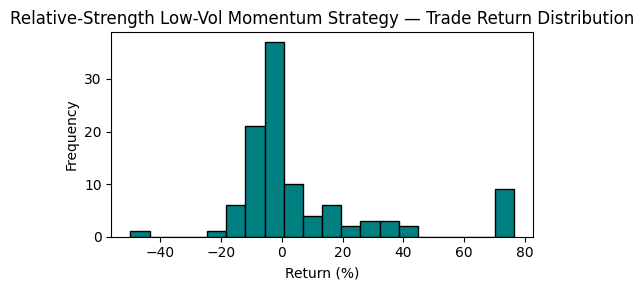

  Completed Trades : 105
  Max Drawdown     : 11.81%
  Final Value      : ₹752,385.37


In [14]:
plot_equity_and_distribution(port_rel_stre, trades_rel_stre, 'Relative-Strength Low-Vol Momentum Strategy')


In [15]:
metrics_rel_stre = compute_alpha_beta_sharpe(port_rel_stre, 'Relative-Strength Low-Vol Momentum Strategy')



--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.49
Annualized Alpha (Formula-based): 2.63%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0252
Annualized Sharpe Ratio: 0.3994


**Key observations:**
- Relative-strength ranking is the most direct available tool for alpha isolation — it literally measures outperformance vs the index.
- The market-regime gate (Nifty > SMA50) prevents opening positions during corrections. The portfolio drifts toward cash in downturns, decoupling returns from the market and reducing beta.
- The stricter vol cap (40%) keeps the universe in genuinely low-beta territory, amplifying the effect of the relative-strength filter.


In [16]:
var_rel_stre = compute_var_analysis(final_rel_stre, 'Relative-Strength Low-Vol Momentum Strategy')



--- Portfolio Holdings Analysis ---
Current holdings value: ₹229,989.74


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,NMDC.NS,424,93.2600,39542.2409,0.1719
1,TORNTPHARM.NS,8,4439.2002,35513.6016,0.1544
2,NTPC.NS,92,361.9000,33294.7994,0.1448
3,COALINDIA.NS,69,474.4000,32733.5996,0.1423
4,HINDALCO.NS,30,1102.5000,33075.0000,0.1438
5,APOLLOHOSP.NS,3,8304.5000,24913.5000,0.1083
6,GRASIM.NS,10,3091.7000,30916.9995,0.1344



--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),7414.0,4534.0,2968.0
Variance-Covariance,6069.0,4219.0,3233.0
Monte Carlo Simulation,6093.0,4221.0,3223.0



--- Traffic Light Analysis ---
Historical (Holdings): Green (1 breaches)
Variance-Covariance: Green (1 breaches)
Monte Carlo Simulation: Green (1 breaches)

--- Kupiec Test Analysis ---
Historical (Holdings): Good (22 breaches, p-value: 0.504)
Variance-Covariance: Good (26 breaches, p-value: 0.871)
Monte Carlo Simulation: Good (25 breaches, p-value: 0.967)


---
## Strategy Comparison Summary


In [17]:
summary = {
    'Original': {
        'Sharpe (Annual)':   metrics_orig['sharpe'],
        'Alpha (Annual %)':  metrics_orig['alpha'],
        'Beta':              metrics_orig['beta'],
        'Final Value (₹)':   f"{port_orig['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_orig):.2f}',
        'Completed Trades':  len(trades_orig),
        'Max Positions':     20,
        'Stop Floor':        '0.70×',
        'Target':            '1.6×',
        'Ranking':           'None',
        'Vol Filter':        'None',
        'Market Gate':       'None',
        'Kupiec (Hist)':     var_orig.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_orig.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_orig.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
    'Low-Volatility Momentum': {
        'Sharpe (Annual)':   metrics_low_vol_mom['sharpe'],
        'Alpha (Annual %)':  metrics_low_vol_mom['alpha'],
        'Beta':              metrics_low_vol_mom['beta'],
        'Final Value (₹)':   f"{port_low_vol_mom['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_low_vol_mom):.2f}',
        'Completed Trades':  len(trades_low_vol_mom),
        'Max Positions':     15,
        'Stop Floor':        '0.87×',
        'Target':            '1.7×',
        'Ranking':           'mom_126d / vol',
        'Vol Filter':        '< 45%',
        'Market Gate':       'None',
        'Kupiec (Hist)':     var_low_vol_mom.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_low_vol_mom.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_low_vol_mom.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
    'Rel-Strength Low-Vol Momentum': {
        'Sharpe (Annual)':   metrics_rel_stre['sharpe'],
        'Alpha (Annual %)':  metrics_rel_stre['alpha'],
        'Beta':              metrics_rel_stre['beta'],
        'Final Value (₹)':   f"{port_rel_stre['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_rel_stre):.2f}',
        'Completed Trades':  len(trades_rel_stre),
        'Max Positions':     15,
        'Stop Floor':        '0.88×',
        'Target':            '1.7×',
        'Ranking':           '(mom_126d − Nifty) / vol',
        'Vol Filter':        '< 40%',
        'Market Gate':       'Nifty > SMA50',
        'Kupiec (Hist)':     var_rel_stre.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_rel_stre.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_rel_stre.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
}

summary_df = pd.DataFrame(summary)
print('\n══════════════════════════════════════════════════════════════')
print('                  STRATEGY COMPARISON SUMMARY')
print('══════════════════════════════════════════════════════════════')
display(summary_df)


══════════════════════════════════════════════════════════════
                  STRATEGY COMPARISON SUMMARY
══════════════════════════════════════════════════════════════


,Original,Low-Volatility Momentum,Rel-Strength Low-Vol Momentum
Sharpe (Annual),0.063,0.4214,0.3994
Alpha (Annual %),-0.81,2.86,2.63
Beta,0.5274,0.5485,0.4897
Final Value (₹),"660,861","762,667","752,385"
Max Drawdown (%),13.85,13.10,11.81
Completed Trades,154,121,105
Max Positions,20,15,15
Stop Floor,0.70×,0.87×,0.88×
Target,1.6×,1.7×,1.7×
Ranking,None,mom_126d / vol,(mom_126d − Nifty) / vol


Markowitz Mean-Variance Optimization
--

Now we see an example of efficient frontier through Markowitz mean-variance optimization. Given a collection of stocks, we see that randomly varying their weights create a boundary on the plot of returns vs volatility. This boundary is called the efficient frontier, where the portfolio has the least volatility for the returns and has the best returns for the volatility. We then analyze the portfolios on the efficient frontier to get the portfolio with the maximum returns, maximum sharpe ratio and the minimum volatility.

Shape of the efficient frontier: If all assets moved in perfect unison (Correlation $= +1.0$), the frontier would be a straight line. However, because assets are not perfectly correlated, they "offset" each other's volatility.

[*********************100%***********************]  5 of 5 completed


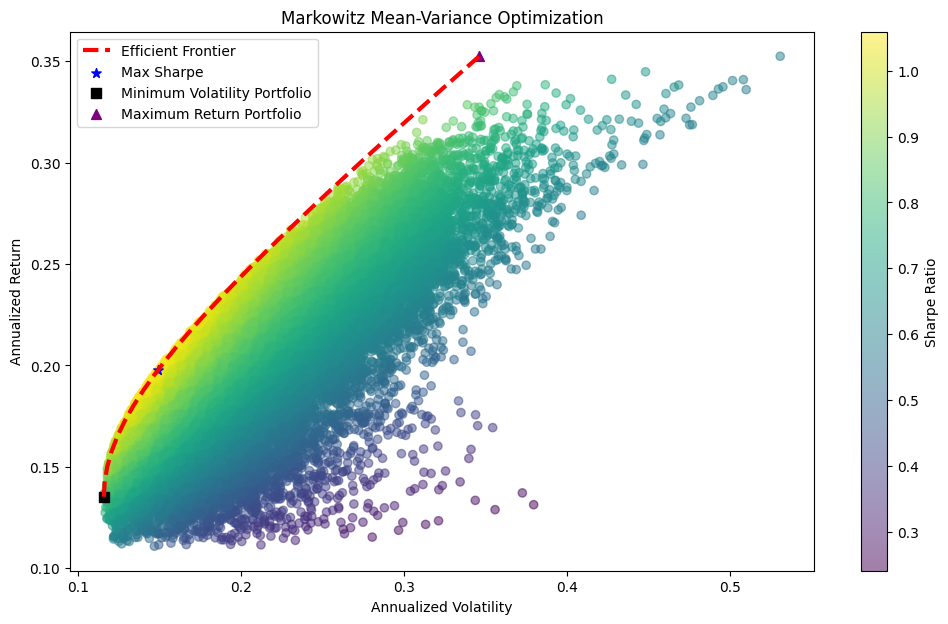

,Minimum Volatility Portfolio,Maximum Return Portfolio,Maximum Sharpe Ratio Portfolio
Sharpe Ratio,0.8233,0.9029,1.0593
Returns,13.53%,35.24%,19.77%
Volatility,11.57%,34.60%,14.88%
AAPL,12.89%,89.85%,34.95%
TLT,0.10%,23.65%,6.89%
GC=F,41.32%,-13.85%,25.55%
BTC-USD,39.41%,11.89%,31.42%
USO,6.28%,-11.54%,1.18%


In [18]:
risk_free_rate = 0.04
n_sim = 50000 # number of portfolios generated

# Define tickers and timeframe
tickers = ['AAPL', 'TLT', 'GC=F', 'BTC-USD', 'USO']
data = yf.download(tickers, start="2019-01-01", end="2024-01-01")['Close']

# Calculate daily logarithmic returns
returns = np.log(data / data.shift(1)).dropna()

# Annualize returns and covariance (252 trading days)
mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

def get_portfolio_metrics(weights, mean_returns, cov_matrix):
    p_ret = np.dot(weights, mean_returns)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return p_ret, p_vol

# The objective function to minimize (Volatility)
def objective_vol(weights, mean_returns, cov_matrix):
    return get_portfolio_metrics(weights, mean_returns, cov_matrix)[1]

# Constraints: Weights must sum to 1.0
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((-1, 1) for _ in range(len(tickers))) # No short-selling, forced to stay diversified

# Minimize Volatility (MVP)
init_guess = [1/len(tickers)] * len(tickers)
opt_mvp = minimize(objective_vol, init_guess, args=(mean_returns, cov_matrix),
                   method='SLSQP', bounds=bounds, constraints=constraints)

# Maximize Sharpe Ratio
def objective_sharpe(weights, mean_returns, cov_matrix, risk_free_rate=0.04):
    p_ret, p_vol = get_portfolio_metrics(weights, mean_returns, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol  # Negative because we 'minimize'

opt_sharpe = minimize(objective_sharpe, init_guess, args=(mean_returns, cov_matrix),
                      method='SLSQP', bounds=bounds, constraints=constraints)

# Display Results
# Simulate n_sim many random portfolios
results = []
for _ in range(n_sim):
    w = np.random.random(len(tickers))
    w /= np.sum(w)
    ret, vol = get_portfolio_metrics(w, mean_returns, cov_matrix)
    results.append([ret, vol, (ret-risk_free_rate)/vol])

res_df = pd.DataFrame(results, columns=['Return', 'Volatility', 'Sharpe'])

# Calculate the Efficient Frontier Line
# We solve for the min volatility at each possible return level
def minimize_vol(weights, mean_returns, cov_matrix):
    return get_portfolio_metrics(weights, mean_returns, cov_matrix)[1]

# Get MVP metrics
mvp_ret, mvp_vol = get_portfolio_metrics(opt_mvp.x, mean_returns, cov_matrix)
mvp_sharpe = (mvp_ret - risk_free_rate) / mvp_vol

# Redefine target returns to start from MVP's return
target_returns = np.linspace(mvp_ret, res_df['Return'].max(), 30)
efficient_vols = []

# Define num_assets correctly for this section
num_assets = len(tickers)

for target in target_returns:
    constraints = (
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}, # Weights sum to 1
        {'type': 'eq', 'fun': lambda x, mr, cm: get_portfolio_metrics(x, mr, cm)[0] - target, 'args': (mean_returns, cov_matrix)} # Return must hit target
    )
    bounds = tuple((-1, 1) for _ in range(num_assets))

    result = minimize(minimize_vol, num_assets*[1./num_assets],
                      args=(mean_returns, cov_matrix), # Pass mean_returns and cov_matrix here
                      method='SLSQP', bounds=bounds, constraints=constraints)
    efficient_vols.append(result['fun'])

# Calculate Maximum Return Portfolio (MRP)
mrp_ret = target_returns[-1] # Highest return on the frontier
# Need to find the weights for this highest return
constraints_mrp = (
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
    {'type': 'eq', 'fun': lambda x, mr, cm: get_portfolio_metrics(x, mr, cm)[0] - mrp_ret, 'args': (mean_returns, cov_matrix)}
)
# Use bounds without short-selling for a more realistic MRP, or (-1,1) for allowing short selling as above
mrp_bounds = tuple((-1, 1) for _ in range(num_assets)) # Changed to allow short selling, consistent with EF
result_mrp = minimize(minimize_vol, num_assets*[1./num_assets],
                      args=(mean_returns, cov_matrix),
                      method='SLSQP', bounds=mrp_bounds, constraints=constraints_mrp)
mrp_weights = result_mrp.x
mrp_ret_actual, mrp_vol = get_portfolio_metrics(mrp_weights, mean_returns, cov_matrix)
mrp_sharpe = (mrp_ret_actual - risk_free_rate) / mrp_vol


# Plot
plt.figure(figsize=(12, 7))
plt.scatter(res_df.Volatility, res_df.Return, c=res_df.Sharpe, cmap='viridis', alpha=0.5)
plt.colorbar(label='Sharpe Ratio')
plt.plot(efficient_vols, target_returns, 'r--', linewidth=3, label='Efficient Frontier')
plt.scatter(get_portfolio_metrics(opt_sharpe.x, mean_returns, cov_matrix)[1],
            get_portfolio_metrics(opt_sharpe.x, mean_returns, cov_matrix)[0],
            color='blue', marker='*', s=50, label='Max Sharpe')
plt.scatter(mvp_vol, mvp_ret, color='black', marker='s', s=50, label='Minimum Volatility Portfolio')
plt.scatter(mrp_vol, mrp_ret_actual, color='purple', marker='^', s=50, label='Maximum Return Portfolio')
plt.title('Markowitz Mean-Variance Optimization')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.legend()
plt.show()

# Find the best portfolio from the random simulations (res_df from previous step)
best_sim_idx = res_df['Sharpe'].idxmax()
max_sharpe_sim = res_df.iloc[best_sim_idx]

# Extract metrics from the mathematical optimizer (opt_sharpe)
# We use the function we defined earlier: get_portfolio_metrics(weights, returns, cov)
opt_ret, opt_vol = get_portfolio_metrics(opt_sharpe.x, mean_returns, cov_matrix)
opt_sharpe_ratio = (opt_ret - risk_free_rate) / opt_vol

# Create the summary table
summary_data = {
    'Minimum Volatility Portfolio': {
        'Sharpe Ratio': f'{mvp_sharpe:.4f}',
        'Returns': f'{mvp_ret:.2%}',
        'Volatility': f'{mvp_vol:.2%}',
    },
    'Maximum Return Portfolio': {
        'Sharpe Ratio': f'{mrp_sharpe:.4f}',
        'Returns': f'{mrp_ret_actual:.2%}',
        'Volatility': f'{mrp_vol:.2%}',
    },
    'Maximum Sharpe Ratio Portfolio': {
        'Sharpe Ratio': f'{opt_sharpe_ratio:.4f}',
        'Returns': f'{opt_ret:.2%}',
        'Volatility': f'{opt_vol:.2%}',
    }
}

# Add weights to the summary data
for i, ticker in enumerate(tickers):
    summary_data['Minimum Volatility Portfolio'][f'{ticker}'] = f'{opt_mvp.x[i]:.2%}'
    summary_data['Maximum Return Portfolio'][f'{ticker}'] = f'{mrp_weights[i]:.2%}'
    summary_data['Maximum Sharpe Ratio Portfolio'][f'{ticker}'] = f'{opt_sharpe.x[i]:.2%}'

summary_df = pd.DataFrame(summary_data)
display(summary_df)


Relative Strength Low-Volatility Momentum with Mean-Variance Optimization Strategy
--

Now we use the a layer of rebalancing at every entry and exit using efficient frontier's maximum sharpe ratio portfolio on top of the relative strength low-volatility momentum strategy.


--- Alpha and Beta Calculation (using formulas) ---
Beta (Covariance/Variance Formula): 0.58
Annualized Alpha (Formula-based): 8.41%

--- Portfolio Sharpe Ratio ---
Daily Sharpe Ratio: 0.0457
Annualized Sharpe Ratio: 0.7259


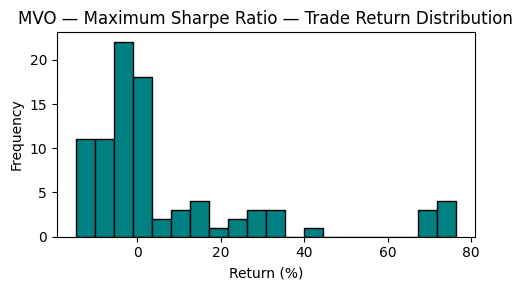

  Completed Trades : 88
  Max Drawdown     : 20.53%
  Final Value      : ₹935,270.90

--- Portfolio Holdings Analysis ---
Current holdings value: ₹125,883.35


,Symbol,Quantity,Current_Price,Current_Value,Weight
0,NTPC.NS,1,361.85,361.8500,0.0029
1,COALINDIA.NS,1,474.40,474.4000,0.0038
2,HINDALCO.NS,88,1102.80,97046.4043,0.7709
3,APOLLOHOSP.NS,3,8303.00,24909.0000,0.1979
4,GRASIM.NS,1,3091.70,3091.7000,0.0246



--- VaR Results Summary (Absolute Loss in ₹) ---


,99%,95%,90%
VaR Method,,,
Historical (Holdings),6107.0,3522.0,2336.0
Variance-Covariance,4934.0,3450.0,2659.0
Monte Carlo Simulation,4783.0,3421.0,2629.0



--- Traffic Light Analysis ---
Historical (Holdings): Green (1 breaches)
Variance-Covariance: Green (4 breaches)
Monte Carlo Simulation: Green (4 breaches)

--- Kupiec Test Analysis ---
Historical (Holdings): Bad (15 breaches, p-value: 0.025)
Variance-Covariance: Bad (15 breaches, p-value: 0.025)
Monte Carlo Simulation: Bad (16 breaches, p-value: 0.044)


In [19]:
tickers = [t + '.NS' for t in nifty_tickers_raw]   # renamed to avoid clobbering MVO tickers

def compute_mvo_weights(active_symbols, date, objective):
    """
    Compute optimal portfolio weights via Markowitz MVO.

    Parameters
    ----------
    active_symbols : list[str]   — tickers currently in the portfolio
    date           : Timestamp   — current backtest date (used to slice history)
    objective      : str         — 'min_vol' | 'max_return' | 'max_sharpe'

    Returns
    -------
    dict {symbol: weight}  (weights sum to 1, all ≥ 0)
    """
    n          = len(active_symbols)
    eq_weights = {s: 1.0 / n for s in active_symbols}

    if n < 2:
        return {s: 1.0 for s in active_symbols}

    # ── Slice historical close prices ending at `date` ──────
    try:
        loc = close_prices.index.get_loc(date)
    except KeyError:
        loc = close_prices.index.searchsorted(date)

    start_loc = max(0, loc - MVO_LOOKBACK)
    hist      = close_prices.iloc[start_loc : loc + 1][active_symbols].dropna(how='any')
    if len(hist) < 30:
        return eq_weights

    log_rets = np.log(hist / hist.shift(1)).dropna()
    if len(log_rets) < 20:
        return eq_weights

    mean_ret = log_rets.mean().values * 252   # annualised
    cov_mat  = log_rets.cov().values  * 252   # annualised

    def port_ret(w): return float(w @ mean_ret)
    def port_vol(w): return float(np.sqrt(np.maximum(w @ cov_mat @ w, 1e-12)))

    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
    bounds = tuple((0.0, 1.0) for _ in range(n))
    w0     = np.ones(n) / n
    opts   = {'ftol': 1e-9, 'maxiter': 1000}

    try:
        if objective == 'min_vol':
            res = minimize(port_vol, w0,
                           method='SLSQP', bounds=bounds,
                           constraints=constraints, options=opts)

        elif objective == 'max_return':
            # Maximise expected return — with long-only constraint this concentrates
            # in the highest-momentum stock; diversification comes from the entry
            # signal requiring the full active set.
            res = minimize(lambda w: -port_ret(w), w0,
                           method='SLSQP', bounds=bounds,
                           constraints=constraints, options=opts)

        else:  # max_sharpe
            def neg_sharpe(w):
                r, v = port_ret(w), port_vol(w)
                return -(r - RISK_FREE_ANNUAL) / (v + 1e-10)
            res = minimize(neg_sharpe, w0,
                           method='SLSQP', bounds=bounds,
                           constraints=constraints, options=opts)

        # Accept solution even with soft non-convergence as long as weights are valid
        w = np.clip(res.x, 0.0, 1.0)
        if w.sum() > 1e-8:
            w = w / w.sum()
            return dict(zip(active_symbols, w))

    except Exception:
        pass

    return eq_weights

def apply_mvo_rebalance(active_trades, row, date, objective):
    """
    Rebalance active_trades IN-PLACE using MVO-derived weights.

    Capital pool is the current mark-to-market value of all active positions.
    Cash in the backtest account absorbs all rounding differences.

    Returns
    -------
    cash_delta : float
        Net cash released (+) or consumed (-) by the rebalance.
    mvo_weights_used : dict
        The weight assigned to each symbol by the optimizer.
    """
    if not active_trades:
        return 0.0, {}

    symbols = [t['symbol'] for t in active_trades]

    # Current prices from the market row
    curr_px = {}
    for t in active_trades:
        p = row.get(t['symbol'], np.nan)
        curr_px[t['symbol']] = p if not np.isnan(p) else t['entry_price']

    # Total invested value (basis for weight allocation)
    invested_val = sum(curr_px[t['symbol']] * t['qty'] for t in active_trades)
    if invested_val <= 0:
        return 0.0, {}

    weights = compute_mvo_weights(symbols, date, objective)

    cash_delta = 0.0
    for t in active_trades:
        sym = t['symbol']
        px  = curr_px[sym]
        if px <= 0:
            continue
        # Target share count; max(1,...) ensures no position is force-closed by MVO
        new_qty    = max(1, round(weights[sym] * invested_val / px))
        cash_delta += (t['qty'] - new_qty) * px   # positive → shares sold → cash in
        t['qty']    = new_qty

    return cash_delta, weights

def run_backtest_mvo_maxsharpe():
    """Rel-Strength Low-Vol Momentum + MVO Maximum Sharpe Ratio rebalancing."""
    OBJECTIVE     = 'max_sharpe'
    MAX_POS       = 15
    VOL_THRESHOLD = 0.40

    cash = INITIAL_CAPITAL
    portfolio_history, completed_trades, active_trades = [], [], []
    rebalance_log = []

    for date, row in close_prices.iterrows():
        curr_val = cash
        for t in active_trades:
            p = row.get(t['symbol'], np.nan)
            if not np.isnan(p): curr_val += p * t['qty']
        portfolio_history.append({'Date': date, 'Value': curr_val,
                                   'Num_Trades': len(active_trades)})

        exit_occurred = False
        for t in active_trades[:]:
            p = row.get(t['symbol'], np.nan)
            if np.isnan(p): continue
            if date.weekday() == 0:
                try:
                    new_sl = float(low_10w.loc[date, t['symbol']])
                    if not np.isnan(new_sl):
                        t['stop_loss'] = max(t['stop_loss'], new_sl)
                except Exception: pass
            if p >= t['target'] or p <= t['stop_loss']:
                cash += p * t['qty']
                completed_trades.append((p - t['entry_price']) / t['entry_price'] * 100)
                active_trades.remove(t)
                exit_occurred = True

        if exit_occurred and active_trades:
            delta, wts = apply_mvo_rebalance(active_trades, row, date, OBJECTIVE)
            cash += delta
            rebalance_log.append({'date': date, 'trigger': 'exit', 'weights': wts})

        if date.weekday() != 0 or len(active_trades) >= MAX_POS:
            continue
        prev_friday = date - timedelta(days=3)
        if prev_friday not in high_52w.index: continue

        try:
            nifty_ok = float(nifty_close.loc[date]) > float(nifty_sma50.loc[date])
        except Exception:
            nifty_ok = True
        if not nifty_ok: continue

        try:
            nifty_mom = float(nifty_mom_126d.loc[prev_friday])
        except Exception:
            nifty_mom = 0.0
        if np.isnan(nifty_mom): nifty_mom = 0.0

        picks = []
        for sym in tickers:
            p = row.get(sym, np.nan)
            if np.isnan(p) or any(t['symbol'] == sym for t in active_trades): continue
            try:
                pf_close  = float(close_prices.loc[prev_friday, sym])
                pf_52h    = float(high_52w.loc[prev_friday, sym])
                pf_turn   = float(avg_turnover.loc[prev_friday, sym])
                pf_vol    = float(vol_60d.loc[prev_friday, sym])
                pf_mom126 = float(mom_126d.loc[prev_friday, sym])
            except Exception: continue
            if any(np.isnan(v) for v in [pf_close, pf_52h, pf_vol, pf_mom126]):
                continue

            if (pf_close >= pf_52h and
                    pf_turn  >= TURNOVER_THRESHOLD and
                    pf_vol   <  VOL_THRESHOLD):
                score = (pf_mom126 - nifty_mom) / (pf_vol + 0.01)
                picks.append((sym, score))

        picks.sort(key=lambda x: x[1], reverse=True)

        entry_occurred = False
        for sym, _ in picks:
            if len(active_trades) >= MAX_POS: break
            ep = row.get(sym, np.nan)
            if np.isnan(ep): continue
            alloc = INITIAL_CAPITAL / MAX_POS
            if cash < alloc: continue
            qty = int(alloc // ep)
            if qty <= 0: continue
            try:
                sl_10w = float(low_10w.loc[date, sym])
            except Exception:
                sl_10w = ep * 0.88
            sl = max(ep * 0.88, sl_10w if not np.isnan(sl_10w) else ep * 0.88)
            cash -= qty * ep
            active_trades.append({'symbol': sym, 'entry_price': ep, 'qty': qty,
                                   'target': ep * 1.7, 'stop_loss': sl})
            entry_occurred = True

        if entry_occurred and active_trades:
            delta, wts = apply_mvo_rebalance(active_trades, row, date, OBJECTIVE)
            cash += delta
            rebalance_log.append({'date': date, 'trigger': 'entry', 'weights': wts})

    return pd.DataFrame(portfolio_history), completed_trades, active_trades, rebalance_log

port_maxsharpe, trades_maxsharpe, final_maxsharpe, log_maxsharpe = run_backtest_mvo_maxsharpe()
metrics_maxsharpe = compute_alpha_beta_sharpe(port_maxsharpe, 'MVO — Maximum Sharpe Ratio')
plot_equity_and_distribution(port_maxsharpe, trades_maxsharpe, 'MVO — Maximum Sharpe Ratio')
var_maxsharpe = compute_var_analysis(final_maxsharpe, 'MVO — Maximum Sharpe Ratio')

Strategy Comparison Summary
--

Finally we summarize this updated strategy along with the previous three strategies. We see that the latest strategy does very well in terms of alpha, but has a slightly worse beta, and about double the drawdown compared to the other three strategies.

In [20]:
summary = {
    'Original': {
        'Sharpe (Annual)':   metrics_orig['sharpe'],
        'Alpha (Annual %)':  metrics_orig['alpha'],
        'Beta':              metrics_orig['beta'],
        'Final Value (₹)':   f"{port_orig['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_orig):.2f}',
        'Completed Trades':  len(trades_orig),
        'Max Positions':     20,
        'Stop Floor':        '0.70×',
        'Target':            '1.6×',
        'Ranking':           'None',
        'Vol Filter':        'None',
        'Market Gate':       'None',
        'Kupiec (Hist)':     var_orig.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_orig.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_orig.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
    'Low-Volatility Momentum': {
        'Sharpe (Annual)':   metrics_low_vol_mom['sharpe'],
        'Alpha (Annual %)':  metrics_low_vol_mom['alpha'],
        'Beta':              metrics_low_vol_mom['beta'],
        'Final Value (₹)':   f"{port_low_vol_mom['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_low_vol_mom):.2f}',
        'Completed Trades':  len(trades_low_vol_mom),
        'Max Positions':     15,
        'Stop Floor':        '0.87×',
        'Target':            '1.7×',
        'Ranking':           'mom_126d / vol',
        'Vol Filter':        '< 45%',
        'Market Gate':       'None',
        'Kupiec (Hist)':     var_low_vol_mom.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_low_vol_mom.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_low_vol_mom.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
    'Rel-Strength Low-Vol Momentum': {
        'Sharpe (Annual)':   metrics_rel_stre['sharpe'],
        'Alpha (Annual %)':  metrics_rel_stre['alpha'],
        'Beta':              metrics_rel_stre['beta'],
        'Final Value (₹)':   f"{port_rel_stre['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_rel_stre):.2f}',
        'Completed Trades':  len(trades_rel_stre),
        'Max Positions':     15,
        'Stop Floor':        '0.88×',
        'Target':            '1.7×',
        'Ranking':           '(mom_126d − Nifty) / vol',
        'Vol Filter':        '< 40%',
        'Market Gate':       'Nifty > SMA50',
        'Kupiec (Hist)':     var_rel_stre.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_rel_stre.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_rel_stre.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
    'Rel-Strength Low-Vol Momentum with MVO': {
        'Sharpe (Annual)':   metrics_maxsharpe['sharpe'],
        'Alpha (Annual %)':  metrics_maxsharpe['alpha'],
        'Beta':              metrics_maxsharpe['beta'],
        'Final Value (₹)':   f"{port_maxsharpe['Value'].iloc[-1]:,.0f}",
        'Max Drawdown (%)':  f'{get_max_drawdown(port_maxsharpe):.2f}',
        'Completed Trades':  len(trades_maxsharpe),
        'Max Positions':     15,
        'Stop Floor':        '0.88×',
        'Target':            '1.7×',
        'Ranking':           '(mom_126d − Nifty) / vol',
        'Vol Filter':        '< 40%',
        'Market Gate':       'Nifty > SMA50',
        'Kupiec (Hist)':     var_maxsharpe.get('kupiec', {}).get('Historical (Holdings)',  'N/A'),
        'Kupiec (VCV)':      var_maxsharpe.get('kupiec', {}).get('Variance-Covariance',    'N/A'),
        'Kupiec (MC)':       var_maxsharpe.get('kupiec', {}).get('Monte Carlo Simulation', 'N/A'),
    },
}

summary_df = pd.DataFrame(summary)
print('\n══════════════════════════════════════════════════════════════')
print('                  STRATEGY COMPARISON SUMMARY')
print('══════════════════════════════════════════════════════════════')
display(summary_df)


══════════════════════════════════════════════════════════════
                  STRATEGY COMPARISON SUMMARY
══════════════════════════════════════════════════════════════


,Original,Low-Volatility Momentum,Rel-Strength Low-Vol Momentum,Rel-Strength Low-Vol Momentum with MVO
Sharpe (Annual),0.063,0.4214,0.3994,0.7259
Alpha (Annual %),-0.81,2.86,2.63,8.41
Beta,0.5274,0.5485,0.4897,0.5819
Final Value (₹),"660,861","762,667","752,385","935,271"
Max Drawdown (%),13.85,13.10,11.81,20.53
Completed Trades,154,121,105,88
Max Positions,20,15,15,15
Stop Floor,0.70×,0.87×,0.88×,0.88×
Target,1.6×,1.7×,1.7×,1.7×
Ranking,None,mom_126d / vol,(mom_126d − Nifty) / vol,(mom_126d − Nifty) / vol


Appendix
--

Here we see with example that the efficient frontier changes with the assumption that stock returns follow certain distribution. The default being the normal distribution, however, in reality, the ditribution must have fatter tails to accomodate extreme events, asymetric (as extreme negative returns are reacted differently compared to extreme positive ones, which occur rarely compared to negative ones), diversification and covariance loses its edge during extreme negative return event. We compare efficient frontiers with normal distribution and t-distribution (for lack of a better realistic distribution).

[*********************100%***********************]  4 of 4 completed


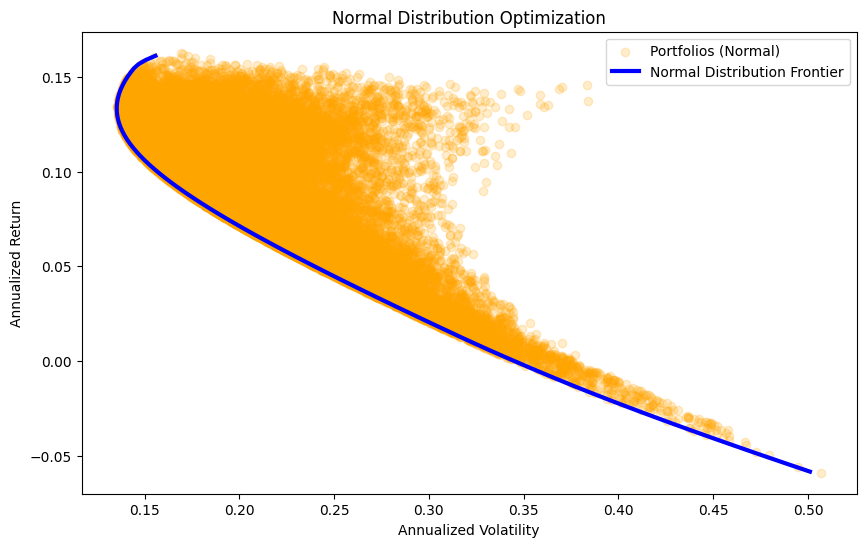

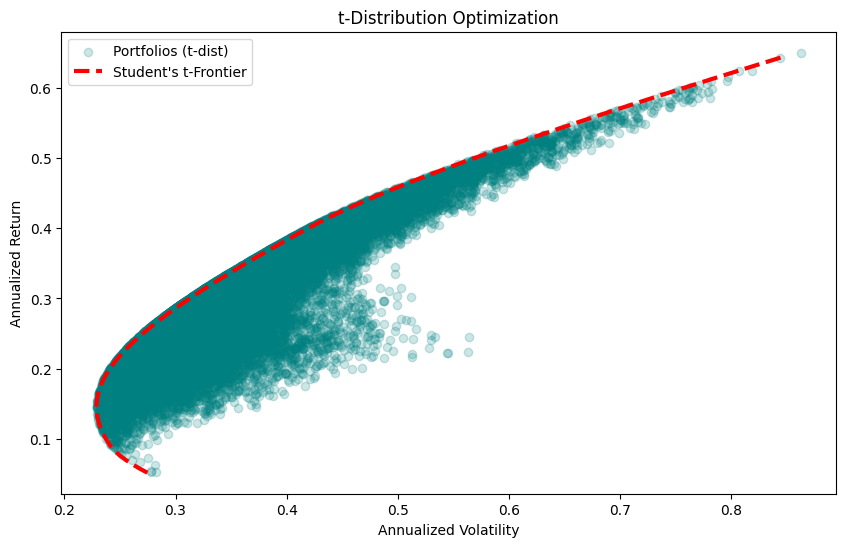

In [21]:
n_sim = 50000

# Generate Data based on t-distribution
tickers = ['AAPL', 'USO', 'GC=F', 'BTC-USD']
n_assets, n_days, df_t = len(tickers), 1000, 3

# Fetch real data
data = yf.download(tickers, start="2020-01-01")['Close']
returns = np.log(data / data.shift(1)).dropna()

# Calculate actual Annualized Targets
ann_rets = returns.mean() * 252
ann_vols = returns.std() * np.sqrt(252)

# Generate returns using the distributions
raw_data_t = t.rvs(df_t, size=(n_days, n_assets))
raw_data_norm = np.random.normal(loc=0, scale=1, size=(n_days, n_assets))
returns_df_t = pd.DataFrame((raw_data_t * (ann_vols.values / np.sqrt(252))) + (ann_rets.values / 252), columns=tickers)
returns_df_norm = pd.DataFrame((raw_data_norm * (ann_vols.values / np.sqrt(252))) + (ann_rets.values / 252), columns=tickers)

# Calculate Empirical Stats (Crucial for the boundary)
mean_rets_t = returns_df_t.mean() * 252
cov_t = returns_df_t.cov() * 252
mean_rets_norm = returns_df_norm.mean() * 252
cov_norm = returns_df_norm.cov() * 252

# Optimization and Simulation
def get_metrics(w):
    p_ret_t = np.dot(w, mean_rets_t)
    p_vol_t = np.sqrt(np.dot(w.T, np.dot(cov_t, w)))
    p_ret_norm = np.dot(w, mean_rets_norm)
    p_vol_norm = np.sqrt(np.dot(w.T, np.dot(cov_norm, w)))
    return p_ret_t, p_vol_t, p_ret_norm, p_vol_norm

sim_data = []
for _ in range(n_sim):
    w = np.random.random(n_assets)
    w /= np.sum(w)
    sim_data.append(get_metrics(w))
sim_df = pd.DataFrame(sim_data, columns=['Return_t', 'Volatility_t', 'Return_Norm', 'Volatility_Norm'])

# Solve for the Efficient Frontier
# Refine target ranges to avoid extreme edges and potential optimization failures
t_min_ret = sim_df['Return_t'].min() * 0.99 # Slightly shrink range
t_max_ret = sim_df['Return_t'].max() * 0.99
target_range_t = np.linspace(t_min_ret, t_max_ret, 100)

norm_min_ret = sim_df['Return_Norm'].min() * 0.99 # Slightly shrink range
norm_max_ret = sim_df['Return_Norm'].max() * 0.99
target_range_norm = np.linspace(norm_min_ret, norm_max_ret, 100)

t_frontier_vols = []
norm_frontier_vols = []

# Initial guess for the first optimization, will be updated iteratively
initial_weights_t = [0.25]*n_assets
initial_weights_norm = [0.25]*n_assets

for tr_norm in target_range_norm:
    cons_norm = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
                 {'type': 'eq', 'fun': lambda x: np.dot(x, mean_rets_norm) - tr_norm})
    res_norm = minimize(lambda w: get_metrics(w)[3], initial_weights_norm, bounds=((0,1),)*n_assets, constraints=cons_norm, method='SLSQP')
    norm_frontier_vols.append(res_norm['fun'])
    initial_weights_norm = res_norm.x # Update initial guess for next iteration

for tr_t in target_range_t:
    cons_t = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
            {'type': 'eq', 'fun': lambda x: np.dot(x, mean_rets_t) - tr_t})
    res_t = minimize(lambda w: get_metrics(w)[1], initial_weights_t, bounds=((0,1),)*n_assets, constraints=cons_t, method='SLSQP')
    t_frontier_vols.append(res_t['fun'])
    initial_weights_t = res_t.x # Update initial guess for next iteration

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(sim_df.Volatility_Norm, sim_df.Return_Norm, color='orange', alpha=0.2, label='Portfolios (Normal)')
plt.plot(norm_frontier_vols, target_range_norm, 'b-', linewidth=3, label="Normal Distribution Frontier")
plt.title("Normal Distribution Optimization")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()
print('\n')
plt.figure(figsize=(10, 6))
plt.scatter(sim_df.Volatility_t, sim_df.Return_t, color='teal', alpha=0.2, label='Portfolios (t-dist)')
plt.plot(t_frontier_vols, target_range_t, 'r--', linewidth=3, label="Student's t-Frontier")
plt.title("t-Distribution Optimization")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.show()